### Detect breaths from the video
[1] https://gist.github.com/pknowledge/623515e8ab35f1771ca2186630a13d14

[2] https://www.learnopencv.com/how-to-select-a-bounding-box-roi-in-opencv-cpp-python/

Code was written by Sijia Gao, sg2329@cornell.edu

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from __future__ import division
import os
from sklearn.decomposition import PCA
from scipy.signal import find_peaks
from scipy.signal import find_peaks, peak_prominences
from sklearn.preprocessing import scale, normalize

In [2]:
fps=30 #video frame rate
ratio=0.01

def crop(frame,r):
    frame=frame[r[1]:r[1]+r[3],r[0]:r[0]+r[2]]
    return frame

In [3]:
def get_ROI(au):
#MANUALLY CHOOSE REGION OF INTEREST SURROUDING ANIMAL'S ABDOMEN WITH UPS AND DOWNS EXCLUSIVE FOR BREATHS 
    
    path_in=os.path.join(path2_dataset,'videos_detectbreaths',au+'.avi')
    cap = cv2.VideoCapture(path_in)
    _,im=cap.read() ##old frame

    
    r = cv2.selectROI(im)
    imCrop = im[int(r[1]):int(r[1]+r[3]), int(r[0]):int(r[0]+r[2])]
    roi=[r[0],r[1],r[2],r[3],0]
    cv2.imshow("Image", imCrop)
    cv2.waitKey(0)
    r=[r[0],r[1],r[2],r[3],0]
        
        
    return r 


In [4]:
#concatenate ROI pixels (grayscale) along frames
def main(inputs,r):
    
    path_in=os.path.join(path2_dataset,'videos_detectbreaths',au+'.avi')
    cap = cv2.VideoCapture(path_in)
    r_matrix=[]
    
    while(cap.isOpened()):
        ret,f= cap.read() 
        if ret:
            f=cv2.cvtColor(crop(f,r[:4]),cv2.COLOR_BGR2GRAY).flatten().tolist()
            r_matrix.append(f)

        else:
            break

    r_matrix=np.array(r_matrix)
    return r_matrix 

In [5]:
def get_breaths(au,r_matrix,r,onset,pca_dim,pthres):
#APPLY PCA TO CONCATENATED ROI PIXELS ALONG THE FRAMEs TO EXTRACT RESPIRATORY TIME SERIES AND BREATHS
#INPUT
#au (name of video)
#r_matrix (concatenated ROI pixels along the frames)
#r (ROI; region of interest)
#onset (onset of movement in video)
#pca_dim (pca dimensionality that represents the respiratory time series)
#pthres (prominence of peaks in the respiratory time series that suggest breaths)
        
        T=len(r_matrix)/fps
        pca=PCA(n_components=3)
        if onset and onset!=-1:
            r_matrix=r_matrix[:int(onset*fps)]
            y=pca.fit_transform(r_matrix)
        else:
            y=pca.fit_transform(r_matrix)
            
        var=pca.explained_variance_ratio_
        print(var)

        fig=plt.figure()
        y=y[:,pca_dim]
        
        if pca_dim!=-1:
            #plot respiratory time series
            tt=np.arange(len(y))/fps
            #Peaks in respiratory time series were detected as breaths
            peaks, _ = find_peaks(y)
            prominences = peak_prominences(y, peaks)[0]
            peaks=peaks[np.where(prominences>pthres)] 
            peaks=peaks[np.where(y[peaks]>0)]
            plt.plot(tt,y)
            plt.plot(tt[peaks],y[peaks],'x')
            plt.xlim([0,40])
            fig.savefig(os.path.join(path2_dataset,'videos_detectbreaths','detect',au+'.png'))
            plt.close
            #save respiratory signals
            np.savetxt(os.path.join(path2_dataset,'videos_detectbreaths','detect',au+'.txt'),y)
            #save timepoints of breaths
            np.savetxt(os.path.join(path2_dataset,'videos_detectbreaths','detect',au+'-detect'+'.txt'),peaks)
            
    
        
        return y

[0.6330723  0.02991607 0.01670249]


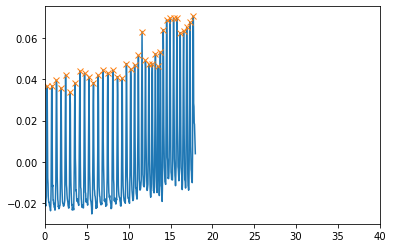

In [6]:
#Add path to dataset
path2_dataset='D:/dataset'

#Name of the video, see 'dataset/videos_detectbreath'
#Each video contains frame 10s before to 20s after the onset of arousal unit
au='9-29'


#Choose region of interest (ROI) 
r=get_ROI(au) 

#Crop videos using ROI
r_matrix=main(au,r)

#Normalize
r_matrix=normalize(r_matrix) 

#Choose pca dimensionality (0-2) that represents the respiratory time series
pca_dim=0
#Prominence in peak detection
prom=0.01 
#Augment ROI with pca and save ROI
r=[r[0],r[1],r[2],r[3],pca_dim]
path=os.path.join(path2_dataset,'videos_detectbreaths','ROI',au+'.txt')
np.savetxt(path,r,fmt="%d")

#Onset of movement in video; if no movement occurred, set onset=-1
onset=18

#Implement pca and detect breaths (orange crosses)
y=get_breaths(au,r_matrix,r,onset,r[-1],prom)